<a href="https://colab.research.google.com/github/AlmasMalik66/DataScience-AI-Assignments/blob/main/Week7/Assignment7_Model%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Import Libraries**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load and Prepare Data**

In [3]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

# Add labels
df_fake['label'] = 1
df_true['label'] = 0

# Combine datasets
df = pd.concat([df_fake, df_true], ignore_index=True)

# Optional: shuffle dataset for randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


**Step 2.1: Select Features and Create Labels**

In [4]:
df['combined_text'] = df['title'] + " " + df['text']
X = df['combined_text']
y = df['label']

# Checking missing values
print(df.isnull().sum())
df = df.dropna(subset=['combined_text'])  # drop rows with empty text




title            0
text             0
subject          0
date             0
label            0
combined_text    0
dtype: int64


**Explanation:**
Since this file only contains fake news, you’ll later merge it with true news (from True.csv) to make it a binary classification dataset.
But for now, we’re preparing the structure.

**Step 2.2: Split Data**

In [5]:
# Step 2.2: Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Train class distribution:
 label
1    18785
0    17133
Name: count, dtype: int64
Test class distribution:
 label
1    4696
0    4284
Name: count, dtype: int64


**Step 3: Convert Text Data to Numeric (TF-IDF Vectorization)**

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform training data, transform test data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization complete!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)


TF-IDF vectorization complete!
Training data shape: (35918, 5000)
Testing data shape: (8980, 5000)


**Explanation:**

* TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numbers based on word importance.
* stop_words='english' removes common words like “the”, “and”, “is”.
* max_features=5000 keeps the top 5000 most important words.
After this, dataset is ready for model training!

**Step 4:Decision Tree & Random Forest**

In [7]:
# 1 Decision Tree Model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_tfidf, y_train)
y_pred_tree = tree_model.predict(X_test_tfidf)

acc_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", round(acc_tree, 3))

# 2 Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf, 3))

# classification report for detailed metrics
print("Decision Tree Report:\n", classification_report(y_test, y_pred_tree))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))


Decision Tree Accuracy: 0.996
Random Forest Accuracy: 0.998
Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



**Step 5:Logistic Regression & Random Forest Comparison**

In [8]:
# 1 Logistic Regression Model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_tfidf, y_train)
y_pred_log = log_model.predict(X_test_tfidf)

acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", round(acc_log, 3))

# 2 Random Forest Model (retrain for comparison)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf, 3))

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))



Logistic Regression Accuracy: 0.988
Random Forest Accuracy: 0.998
Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.98      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# **Model Evaluation**

**Step 6: Import Evaluation Metrics**

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


# **Class Task**
1.Confusion matrix

2.ROC curve.


**Step 7: Confusion Matrix for Logistic Regression**

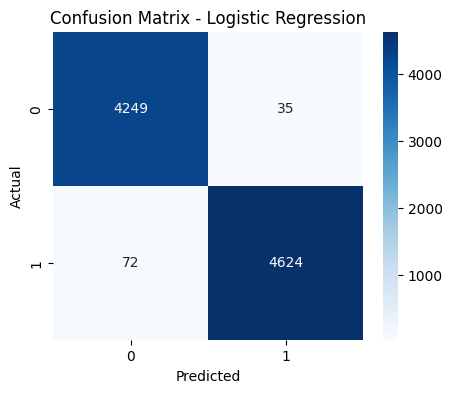

In [10]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Explanation:**
* Shows how many fake/real news articles were correctly or incorrectly predicted.
* Top-left → True Real News
* Bottom-right → True Fake News

**Step 8: ROC Curve and AUC Score**

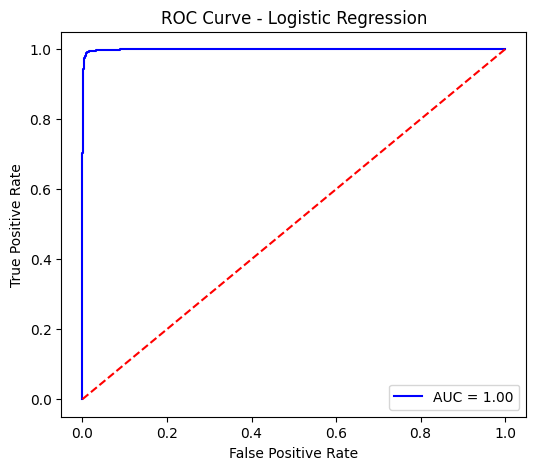

AUC Score: 0.9992362930407824


In [11]:
# ROC Curve and AUC Score for Logistic Regression
y_pred_prob = log_model.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", auc_score)


**Explanation:**
* ROC Curve shows how well the model separates fake vs real news.
* AUC Score close to 1.0 = Excellent model performance.

# **Assignment 7 – Evaluate with Precision, Recall, F1**

**Step 1: Get Classification Report**

In [18]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate detailed classification report for Logistic Regression
report = classification_report(y_test, y_pred_log, output_dict=True)

# Convert to DataFrame for clean display
df_report = pd.DataFrame(report).transpose()
df_report


,precision,recall,f1-score,support
0,0.983337,0.991830,0.987565,4284.000000
1,0.992488,0.984668,0.988562,4696.000000
accuracy,0.988085,0.988085,0.988085,0.988085
macro avg,0.987912,0.988249,0.988064,8980.000000
weighted avg,0.988122,0.988085,0.988087,8980.000000


**Step 2: Display the Report in Simple Text Format**

In [19]:
print("Logistic Regression Evaluation Report")
print(classification_report(y_test, y_pred_log))


Logistic Regression Evaluation Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.98      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



**Reflection: Which Metric Matters Most?**

* For the Fake News Detection project, **Recall** is the most important metric.  
* The purpose of the model is to identify fake news accurately and avoid missing any fake article.  
* A high Recall ensures that most fake news articles are detected correctly, even if some real ones are misclassified.  
* This helps reduce misinformation spread.  
* The **F1 Score** is also useful to keep a balance between Precision and Recall.

# **Project Milestone: Final Evaluation Metric**
- **Chosen Metric:** Recall (Primary), F1-Score (Secondary)
- **Reason:** In fake news detection, false negatives (fake news labeled as real) are more dangerous than false positives.
